In [1]:
import math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from Univariate_LR import compute_model, compute_cost, compute_gradient, gradient_descent

# Univariate Linear Regression

| <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|: ------------|: ------------------------------------------------------------||
| $a$ | scalar, non bold                                                      ||
| $\mathbf{a}$ | vector, bold                                                      ||
| **Regression** |         |    |     |
|  $\mathbf{x}$ | Training Example feature values (in this lab - Size (1000 sqft))  | `x_train` |   
|  $\mathbf{y}$  | Training Example  targets (in this lab Price (1000s of dollars))  | `y_train` 
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `x_i`, `y_i`|
| m | Number of training examples | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $f_{w,b}(x^{(i)})$ | The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$  | `f_wb` | 

In [2]:
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train = np.array([300.0, 500.0, 700, 900, 1100])
df = pd.DataFrame({"sizes": x_train, 
                   "prices": y_train})
df

,sizes,prices
0,1.0,300.0
1,2.0,500.0
2,3.0,700.0
3,4.0,900.0
4,5.0,1100.0


#### array.shape

In [3]:
m = x_train.shape
print(f"x_train.shape: {m}")
print(f"Number of training examples is: {m[0]}")
# OR
print(f"Number of training examples is: {len(x_train)}")

x_train.shape: (5,)
Number of training examples is: 5
Number of training examples is: 5


### Plot the data points

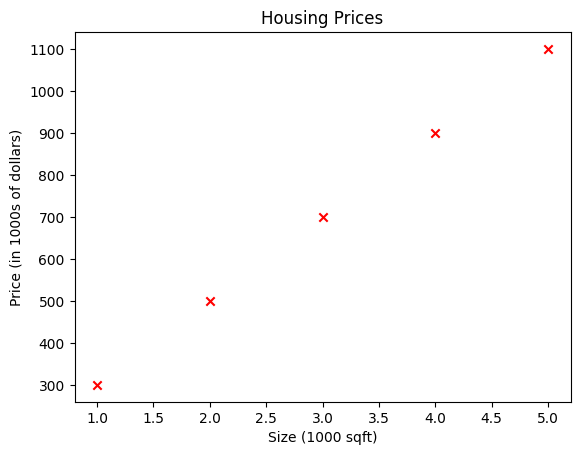

In [4]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()

## Play with w, b to find the best one

In [5]:
w = 200
b = 100

### Model

In [6]:
model_output = compute_model(x_train, w, b)
print(model_output)

[ 300.  500.  700.  900. 1100.]


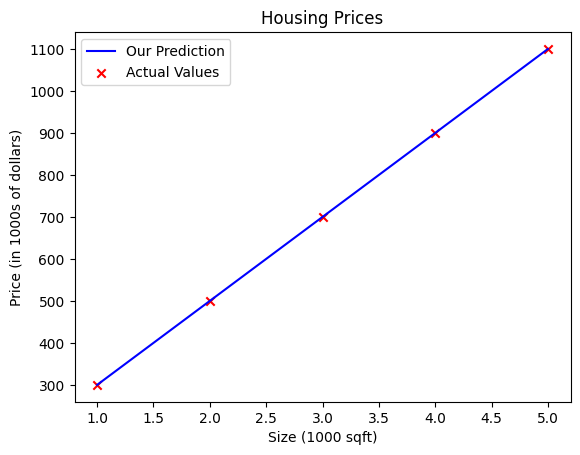

In [7]:
plt.plot(x_train, model_output, c='blue', label = 'Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label = 'Actual Values')

plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')

plt.legend()
plt.show()

# Loss Function

$$ \text {cost} = \sum\limits_{i = 0}^{m-1} (w \cdot x^{(i)} + b) - y^{(i)})^2$$ 
$$ \text {total_cost = } \frac{1}{2m}  \text {cost}$$

In [8]:
model_cost = compute_cost(x_train, y_train, w, b, model=compute_model)
model_cost

0.0

# Gradient

$$ \frac{\text{dj}}{\text{dw}} = \frac{1}{m} \sum\limits_{i=0}^{m-1} ((w \cdot x^{(i)} + b) - y^{(i)}) \cdot {x^{(i)}} $$
$$ \frac{\text{dj}}{\text{db}} = \frac{1}{m} \sum\limits_{i=0}^{m-1} ((w \cdot x^{(i)} + b) - y^{(i)}) $$

# Gradient Descent

$$ \text{W} = \text{W} - \alpha \cdot \frac{\text{dj}}{\text{dW}}$$
$$ \text{b} = \text{b} - \alpha \cdot \frac{\text{dj}}{\text{db}}$$

In [9]:
w_final, b_final, J_hist, p_hist = gradient_descent(x = np.array([1.0, 2.0]),
                     y = np.array([300.0, 500.0]),
                     w_in = 0,
                     b_in = 0,
                     alpha = 1.0e-2,
                     num_iters = 50000)

print(f"(w,b) found by gradient descent: ({w_final:8.4f}, {b_final:8.4f})")

Iteration      0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration   5000: Cost 9.95e-03  dj_dw: -2.004e-02, dj_db:  3.243e-02   w:  1.997e+02, b: 1.00444e+02
Iteration  10000: Cost 6.74e-06  dj_dw: -5.215e-04, dj_db:  8.439e-04   w:  2.000e+02, b: 1.00012e+02
Iteration  15000: Cost 4.56e-09  dj_dw: -1.357e-05, dj_db:  2.196e-05   w:  2.000e+02, b: 1.00000e+02
Iteration  20000: Cost 3.09e-12  dj_dw: -3.532e-07, dj_db:  5.714e-07   w:  2.000e+02, b: 1.00000e+02
Iteration  25000: Cost 2.09e-15  dj_dw: -9.191e-09, dj_db:  1.487e-08   w:  2.000e+02, b: 1.00000e+02
Iteration  30000: Cost 1.42e-18  dj_dw: -2.393e-10, dj_db:  3.869e-10   w:  2.000e+02, b: 1.00000e+02
Iteration  35000: Cost 1.00e-21  dj_dw: -7.077e-12, dj_db:  9.862e-12   w:  2.000e+02, b: 1.00000e+02
Iteration  40000: Cost 1.26e-23  dj_dw: -1.421e-12, dj_db:  7.105e-13   w:  2.000e+02, b: 1.00000e+02
Iteration  45000: Cost 1.26e-23  dj_dw: -1.421e-12, dj_db:  7.105e-13   w:  2.000e

In [ ]:
# In 40,000 iteration we obtain the minimum

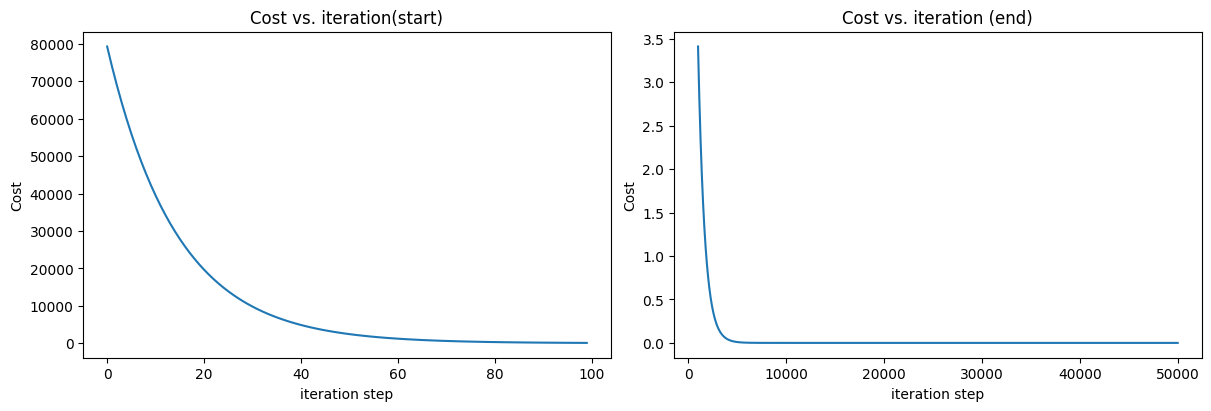

In [10]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)")
ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')
ax2.set_xlabel('iteration step') 
plt.show()

In [11]:
# predictions
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


In [12]:
# Increased Learning Rate

w_final, b_final, J_hist, p_hist = gradient_descent(x = np.array([1.0, 2.0]),
                     y = np.array([300.0, 500.0]),
                     w_in = 0,
                     b_in = 0,
                     alpha = 5.0e-1,
                     num_iters = 1000)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration      0: Cost 4.33e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  3.250e+02, b: 2.00000e+02
Iteration    100: Cost 8.09e-03  dj_dw: -1.875e-02, dj_db:  3.033e-02   w:  1.998e+02, b: 1.00401e+02
Iteration    200: Cost 4.79e-06  dj_dw: -4.563e-04, dj_db:  7.382e-04   w:  2.000e+02, b: 1.00010e+02
Iteration    300: Cost 2.84e-09  dj_dw: -1.111e-05, dj_db:  1.797e-05   w:  2.000e+02, b: 1.00000e+02
Iteration    400: Cost 1.68e-12  dj_dw: -2.703e-07, dj_db:  4.374e-07   w:  2.000e+02, b: 1.00000e+02
Iteration    500: Cost 9.97e-16  dj_dw: -6.579e-09, dj_db:  1.065e-08   w:  2.000e+02, b: 1.00000e+02
Iteration    600: Cost 5.90e-19  dj_dw: -1.601e-10, dj_db:  2.591e-10   w:  2.000e+02, b: 1.00000e+02
Iteration    700: Cost 3.50e-22  dj_dw: -3.979e-12, dj_db:  6.253e-12   w:  2.000e+02, b: 1.00000e+02
Iteration    800: Cost 2.10e-25  dj_dw: -2.842e-14, dj_db:  1.990e-13   w:  2.000e+02, b: 1.00000e+02
Iteration    900: Cost 1.62e-27  dj_dw: -2.842e-14, dj_db:  0.000e+00   w:  2.000e

In [ ]:
# In 900 iteration we obtain the minimum

In [13]:
1000+np.arange(len(J_hist[100:]))

array([1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010,
       1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021,
       1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032,
       1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043,
       1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054,
       1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065,
       1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076,
       1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087,
       1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098,
       1099, 1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109,
       1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120,
       1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131,
       1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142,
       1143, 1144, 1145, 1146, 1147, 1148, 1149, 11

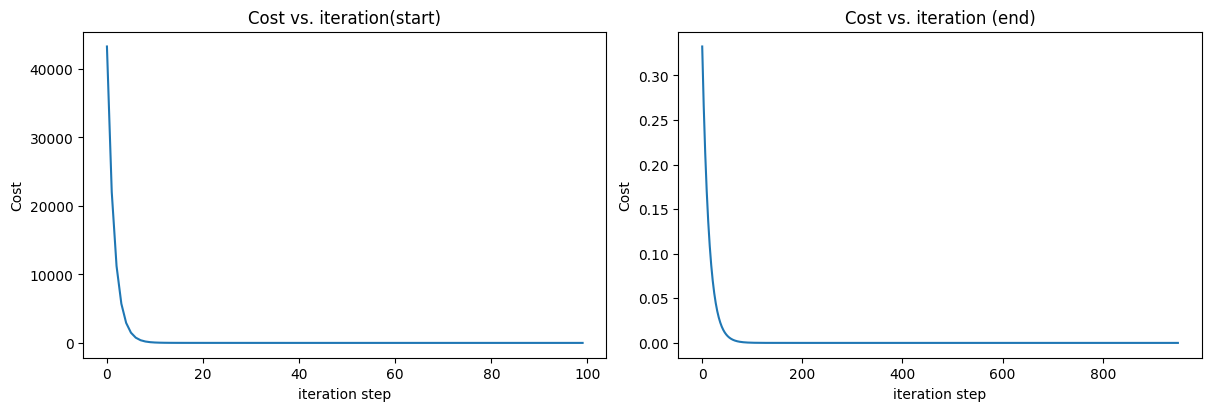

In [14]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(np.arange(len(J_hist[50:])), J_hist[50:])
ax1.set_title("Cost vs. iteration(start)")
ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')
ax2.set_xlabel('iteration step') 
plt.show()

In [15]:
# predictions
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars
